# Student Habits vs Academic Performance — Exploratory Data Analysis

This project performs an exploratory data analysis (EDA) on the Student Habits vs Academic Performance dataset to identify relationships between academic behaviors, lifestyle factors, and exam outcomes.

The analysis focuses on identifying statistically meaningful relationships between study habits, lifestyle patterns, and student performance.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SciPy

## Table of Contents

1. Objective  
2. Dataset Overview  
3. Data Loading  
4. Data Validation & Cleaning  
5. Feature Understanding  
6. Univariate Analysis  
7. Bivariate Analysis  
8. Statistical Tests  
9. Correlation Matrix  
10. Key Insights  
11. Limitations  
12. Next Steps

## 1. Objective


The goal of this analysis is to explore how different student habits relate to exam performance.

Specifically, the analysis examines:

* Which habits (study time, sleep, social media use, etc.) show the strongest relationship with exam scores
* Whether these relationships appear positive, negative, or weak  
* Whether categorical factors such as gender, part-time jobs, or extracurricular activities are associated with differences in average exam scores.

This is an exploratory analysis, meaning the results show associations between variables but do not imply causation


## 2. Dataset Overview

* **Source**: Kaggle (Student Habits vs Academic Performance)
* **Observations**: 1000 students
* **Features**: Demographic, academic, and lifestyle variables
* **Target variable**: `exam_score`



## 3. Data Loading & Reproducibility

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


pd.set_option('display.max_columns', None)
df = pd.read_csv("student_habits_performance.csv")
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## 4. Data Validation & Cleaning

### 4.1 Shape & Types

In [2]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

### 4.2 Missing Values

In [3]:
df.isnull().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [4]:
df['parental_education_level'] = df['parental_education_level'].fillna('Unknown')

### 4.3 Range & Sanity Checks

In [5]:
assert df['sleep_hours'].between(0, 24).all()
assert df['study_hours_per_day'].between(0, 24).all()
assert df['social_media_hours'].between(0, 24).all()
assert df['attendance_percentage'].between(0, 100).all()
assert df['exam_score'].between(0, 100).all()

The following assertions verify that numeric variables fall within realistic ranges and help detect potential data quality issues.

## 5. Variable Types

Understanding variable types helps determine appropriate visualizations and statistical methods for the analysis.

### Numerical Variables

* `study_hours_per_day`
* `sleep_hours`
* `social_media_hours`
* `attendance_percentage`
* `exam_score`

### Ordinal Categorical Variables

* `diet_quality` (ordered category: Poor < Average < Good)
* `parental_education_level`

### Nominal Categorical Variables

* `gender`
* `part_time_job`
* `extracurricular_activities`

## 6. Univariate Analysis (Distribution-Level Insights)

### 6.1 Exam Score Distribution

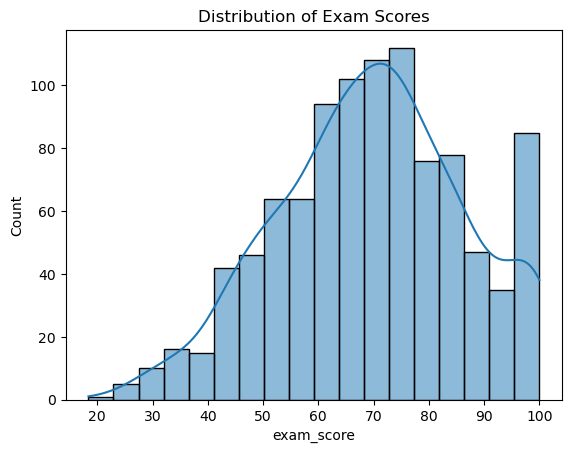

In [6]:
sns.histplot(df['exam_score'], kde=True)
plt.title('Distribution of Exam Scores')
plt.show()

**Observations**:

* Exam scores display a roughly bell-shaped distribution, suggesting an approximately normal pattern.
* Most scores cluster between roughly 55 and 85.
* No strong skewness or extreme outliers are visible.



### 6.2 Study Hours & Sleep

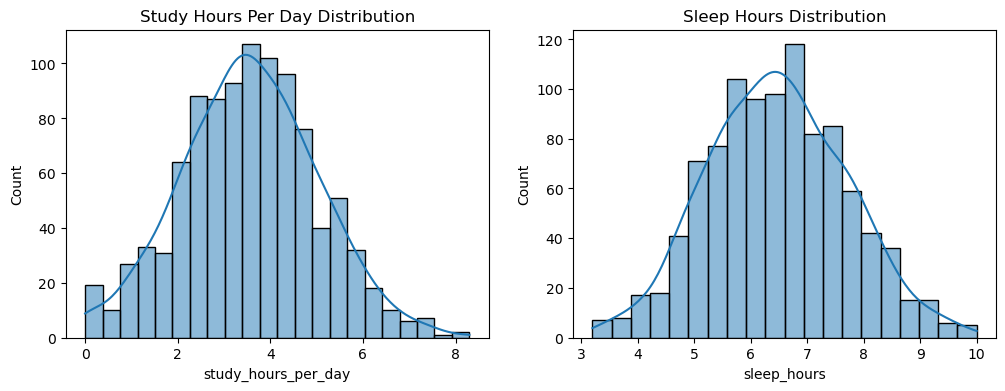

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['study_hours_per_day'], kde=True, ax=ax[0])
ax[0].set_title("Study Hours Per Day Distribution")
sns.histplot(df['sleep_hours'], kde=True, ax=ax[1])
ax[1].set_title("Sleep Hours Distribution")
plt.show()

**Observations**:

* Study hours appear right-skewed, with most students studying roughly 1–4 hours per day 
* Sleep hours cluster tightly around 6–8 hours


### 6.3 Outlier Analysis

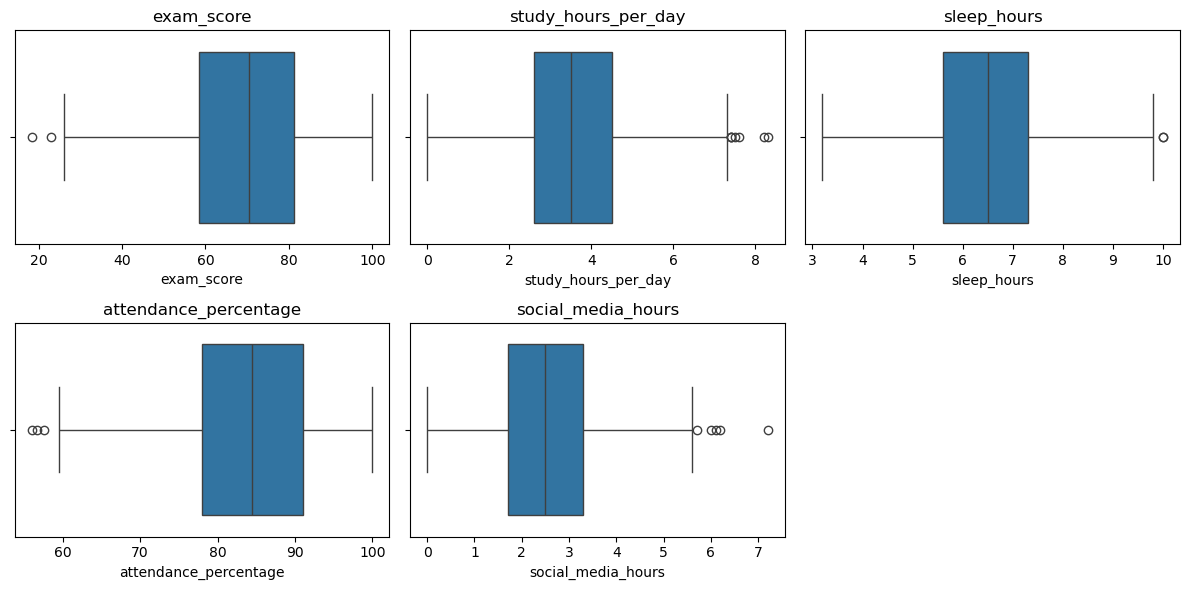

In [11]:
num_cols = [
    'exam_score',
    'study_hours_per_day',
    'sleep_hours',
    'attendance_percentage',
    'social_media_hours'
]

plt.figure(figsize=(12,6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

**Observations**:

Observed outliers fall within realistic human behavior ranges and are retained to preserve real-world variability.


## 7. Bivariate Analysis (Quantified Relationships)

### 7.1 Study Hours vs Exam Score

### Correlation Assumption Check

Before computing correlation coefficients, linearity and variance patterns are visually inspected.


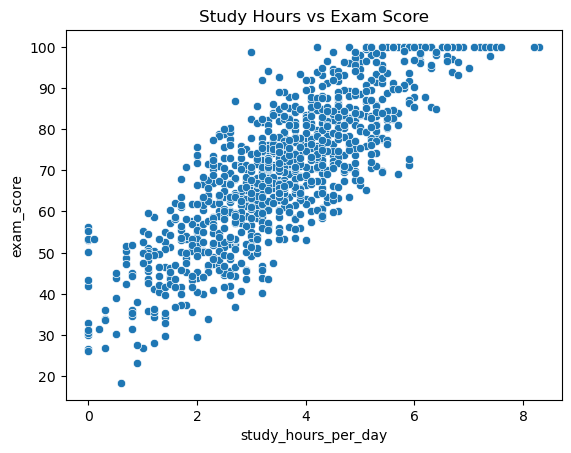

(np.float64(0.8254185093960442), np.float64(4.595701453345378e-250))

In [15]:
sns.scatterplot(x='study_hours_per_day', y='exam_score', data=df)
plt.title("Study Hours vs Exam Score")
plt.show()

corr, p = stats.pearsonr(df['study_hours_per_day'], df['exam_score'])
corr, p


**Observations**:

* Study hours per day show a strong positive correlation with exam scores (r ≈ 0.83).
* Students who spend more time studying tend to achieve higher exam scores.
* The relationship is statistically significant (p < 0.001).

### 7.2 Sleep Hours vs Exam Score

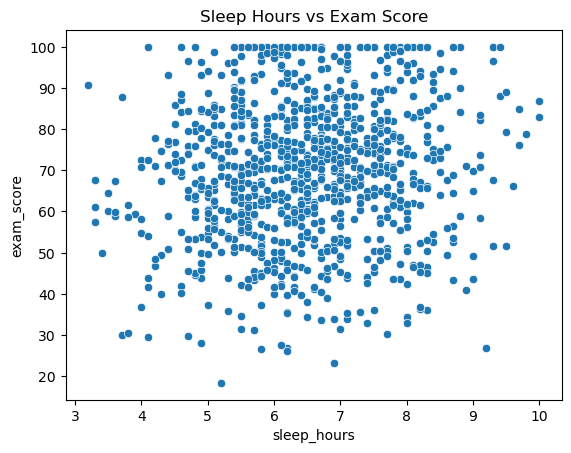

(np.float64(0.12339572915759879), np.float64(9.146088992657371e-05))

In [18]:
sns.scatterplot(x='sleep_hours', y='exam_score', data=df)
plt.title("Sleep Hours vs Exam Score")
plt.show()

corr, p = stats.spearmanr(df['sleep_hours'], df['exam_score'])
corr, p

**Observations**:

* Sleep hours show a weak positive monotonic relationship with exam scores (ρ ≈ 0.12).  
* The relationship is statistically significant (p < 0.001), although the effect size is small.
* This suggests that sleep duration has only a limited association with exam performance in this dataset.

### 7.3 Social Media Usage vs Exam Score

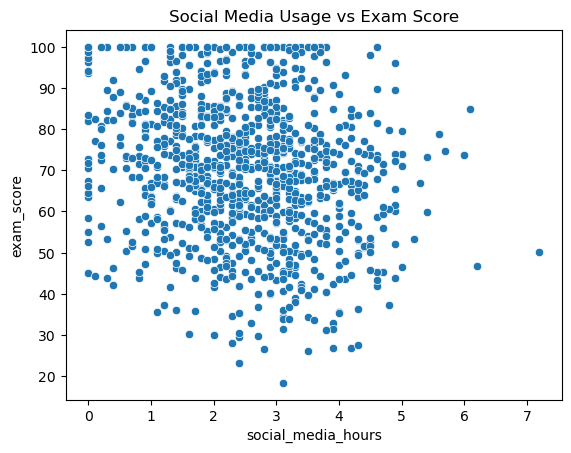

(np.float64(-0.16673288510861672), np.float64(1.1383673090665536e-07))

In [21]:
sns.scatterplot(x='social_media_hours', y='exam_score', data=df)
plt.title("Social Media Usage vs Exam Score")

plt.show()

corr, p = stats.pearsonr(df['social_media_hours'], df['exam_score'])
corr, p

**Observations**:

* Social media usage shows a weak negative correlation with exam scores (r ≈ −0.17). 
* The relationship is statistically significant (p < 0.001), although the effect size is small.
* This suggests that higher social media usage is slightly associated with lower exam scores, but the relationship is not strong enough to serve as a reliable predictor of academic performance.

## 8. Categorical Analysis with Statistical Tests

### 8.1 Gender vs Exam Score (t-test)


In [25]:
male = df[df['gender']=='Male']['exam_score']
female = df[df['gender']=='Female']['exam_score']

t_stat, p_val = stats.ttest_ind(male, female, equal_var=False)
t_stat, p_val

(np.float64(-0.3390592099103262), np.float64(0.7346396273302549))

**Observations**:

Two-sample t-test comparing exam scores by gender:

t = -0.34  
p = 0.73

• The p-value (0.73) is much greater than the common significance threshold of 0.05.  
• Therefore, there is no statistically significant difference in exam scores between male and female students.  
• In this dataset, gender does not appear to meaningfully influence exam performance.

### 8.2 Part-Time Job (t-test)

In [26]:
job = df[df['part_time_job']=='Yes']['exam_score']
no_job = df[df['part_time_job']=='No']['exam_score']
t_stat, p_val = stats.ttest_ind(job, no_job, equal_var=False)
t_stat, p_val

(np.float64(-0.8522990042717021), np.float64(0.3946364639859088))

**Observations**:

Two-sample t-test comparing exam scores for students with and without part-time jobs:

t = -0.85  
p = 0.39

• The p-value (0.39) is greater than the common significance threshold of 0.05.  
• Therefore, there is no statistically significant difference in exam scores between students with and without part-time jobs.  
• Although the average scores may differ slightly, the difference is not statistically meaningful.

### 8.3 Extracurricular Activities (t-test)

In [30]:
extra = df[df['extracurricular_participation']=='Yes']['exam_score']
no_extra = df[df['extracurricular_participation']=='No']['exam_score']

t_stat, p_val = stats.ttest_ind(extra, no_extra)
t_stat, p_val

(np.float64(0.02782137289883962), np.float64(0.9778101815863728))

**Observations**:

Two-sample t-test comparing exam scores for students with and without extracurricular activities:

t = 0.03  
p = 0.98

* The p-value (0.98) is far greater than the significance threshold of 0.05.

* Therefore, there is no statistically significant difference in exam scores between students who participate in extracurricular activities and those who do not.

* In this dataset, extracurricular participation does not appear to meaningfully influence exam performance.

## 9. Multivariate View: Correlation Matrix


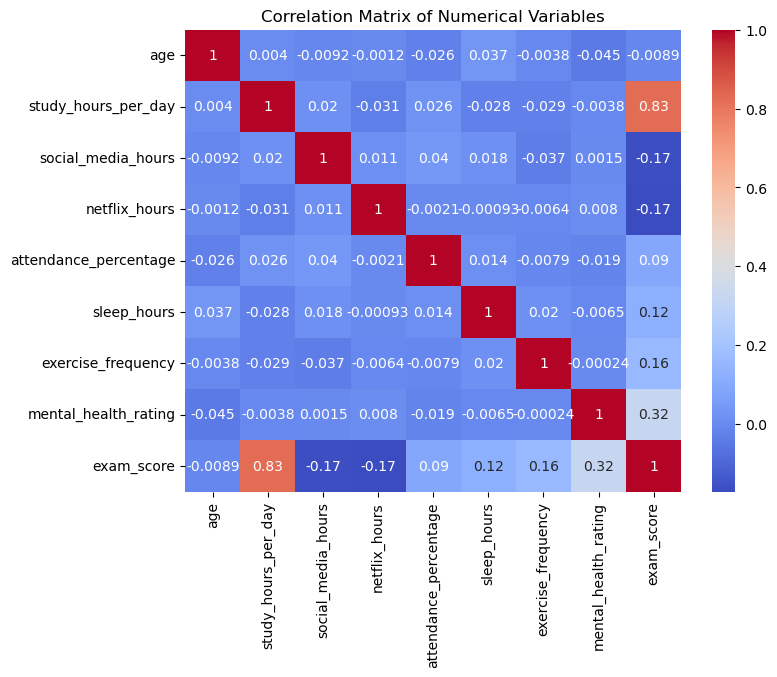

In [27]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

**Observations**:

• Study hours per day show the strongest positive correlation with exam scores (r ≈ 0.83), indicating a strong association between study effort and academic performance.

• Mental health rating shows a moderate positive correlation with exam scores (r ≈ 0.32).

• Exercise frequency and sleep hours show weak positive relationships with exam performance.

• Social media usage and Netflix viewing show weak negative correlations with exam scores.

• Age and attendance percentage show little to no meaningful correlation with exam performance.

## 11. Key Insights (Actionable & Quantified)

1. Study hours have the strongest relationship with exam performance, showing a moderate positive correlation.
2. Attendance percentage consistently correlates with higher scores, reinforcing the importance of classroom engagement.
3. Lifestyle factors (sleep, diet, social media) show weak standalone effects but may influence outcomes when interacting with academic behaviors.
4. Gender and extracurricular participation do not produce statistically significant differences in exam scores.
5. Variability in performance among high-study students suggests that efficiency, not just total hours, may play a role.



## 11. Key Insights

1. Study hours per day show the strongest relationship with exam performance (r ≈ 0.83), indicating a strong association between study effort and academic outcomes.

2. Mental health rating shows a moderate positive correlation with exam scores (r ≈ 0.32).

3. Lifestyle variables such as sleep hours and exercise frequency show weak positive relationships with exam performance.

4. Entertainment usage (social media and Netflix viewing) shows weak negative correlations with exam scores.

5. Statistical tests show no significant differences in exam scores between male and female students, and no significant effects of part-time employment or extracurricular participation.

## 12. Limitations

• The dataset may contain synthetic or simulated patterns.

• Correlation-based analysis does not imply causation.

• The analysis does not model interaction effects or predictive relationships.

## 13. Next Steps

• Build a regression model to quantify how study habits, lifestyle variables, and mental health collectively influence exam performance.

• Apply clustering techniques to identify groups of students with similar behavioral patterns and academic outcomes.

• Validate these findings using a real-world educational dataset to assess whether the observed relationships generalize beyond this dataset.

## 14. Conclusion

This exploratory analysis examined relationships between student habits and academic performance.

The analysis revealed that study hours per day show a strong association with exam scores, while most lifestyle variables such as sleep, exercise, and entertainment usage demonstrate relatively weak standalone effects.

Statistical tests indicate no significant differences in exam performance across gender, part-time employment status, or extracurricular participation.

Overall, the findings suggest that consistent academic effort remains the most influential factor associated with exam outcomes in this dataset.